# K-Nearest Neighbors (K-NN)

### 1. Importación de librerías

En esta celda, importamos las librerías principales que utilizaremos para nuestro ejercicio de K-Nearest Neighbors (KNN).

* **`numpy`** (`np`): Esencial para operaciones numéricas y manipulación de arrays.
* **`matplotlib.pyplot`** (`plt`): La usaremos para la visualización de datos, como la creación de gráficos y diagramas.
* **`pandas`** (`pd`): Nos permite trabajar con estructuras de datos, como DataFrames, facilitando la carga y el preprocesamiento de nuestros datos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 2. Carga y preparación de los datos

En esta sección, cargamos nuestro conjunto de datos y lo dividimos en las variables de entrada (`X`) y la variable objetivo (`y`).

* **`dataset = pd.read_csv(...)`**: Cargamos el archivo CSV `Social_Network_Ads.csv` en un DataFrame de pandas.
* **`X = dataset.iloc[:, :-1].values`**: Seleccionamos todas las filas (`:`) y todas las columnas excepto la última (`:-1`). Estas son nuestras **variables independientes** o características (ej. Edad, Salario estimado). El `.values` convierte el DataFrame en un array de NumPy.
* **`y = dataset.iloc[:, -1].values`**: Seleccionamos todas las filas y solo la última columna (`-1`), que es la variable que queremos predecir. En este caso, si el usuario compró el producto o no (`Purchased`). Al igual que con `X`, convertimos esta serie de pandas a un array de NumPy.

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


### 3. División del conjunto de datos

En esta etapa, dividimos nuestros datos en conjuntos de entrenamiento y de prueba para evaluar el rendimiento de nuestro modelo de manera imparcial.

* **`train_test_split(...)`**: Esta función de `scikit-learn` nos permite dividir nuestros datos de forma aleatoria.
* **`X_train, X_test, y_train, y_test`**: Son las cuatro variables resultantes de la división:
    * `X_train`: Las características para **entrenar** el modelo.
    * `X_test`: Las características que usaremos para **probar** el modelo.
    * `y_train`: La variable objetivo correspondiente al conjunto de entrenamiento.
    * `y_test`: La variable objetivo correspondiente al conjunto de prueba.
* **`test_size = 0.25`**: Indica que el 25% de los datos se asignará al conjunto de prueba, y el 75% restante al de entrenamiento.
* **`random_state = 0`**: Fija la semilla para la división aleatoria. Esto garantiza que obtendremos la misma división cada vez que ejecutemos el código, lo que hace que los resultados sean **reproducibles**.

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [5]:
print(X_train)

[[    44  39000]
 [    32 120000]
 [    38  50000]
 [    32 135000]
 [    52  21000]
 [    53 104000]
 [    39  42000]
 [    38  61000]
 [    36  50000]
 [    36  63000]
 [    35  25000]
 [    35  50000]
 [    42  73000]
 [    47  49000]
 [    59  29000]
 [    49  65000]
 [    45 131000]
 [    31  89000]
 [    46  82000]
 [    47  51000]
 [    26  15000]
 [    60 102000]
 [    38 112000]
 [    40 107000]
 [    42  53000]
 [    35  59000]
 [    48  41000]
 [    48 134000]
 [    38 113000]
 [    29 148000]
 [    26  15000]
 [    60  42000]
 [    24  19000]
 [    42 149000]
 [    46  96000]
 [    28  59000]
 [    39  96000]
 [    28  89000]
 [    41  72000]
 [    45  26000]
 [    33  69000]
 [    20  82000]
 [    31  74000]
 [    42  80000]
 [    35  72000]
 [    33 149000]
 [    40  71000]
 [    51 146000]
 [    46  79000]
 [    35  75000]
 [    38  51000]
 [    36  75000]
 [    37  78000]
 [    38  61000]
 [    60 108000]
 [    20  82000]
 [    57  74000]
 [    42  65000]
 [    26  8000

In [6]:
print(y_train)

[0 1 0 1 1 1 0 0 0 0 0 0 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 1 0 1 0 0 1
 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1
 1 1 0 0 1 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0
 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0
 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0
 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0
 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1
 0 0 0 0]


In [7]:
print(X_test)

[[    30  87000]
 [    38  50000]
 [    35  75000]
 [    30  79000]
 [    35  50000]
 [    27  20000]
 [    31  15000]
 [    36 144000]
 [    18  68000]
 [    47  43000]
 [    30  49000]
 [    28  55000]
 [    37  55000]
 [    39  77000]
 [    20  86000]
 [    32 117000]
 [    37  77000]
 [    19  85000]
 [    55 130000]
 [    35  22000]
 [    35  47000]
 [    47 144000]
 [    41  51000]
 [    47 105000]
 [    23  28000]
 [    49 141000]
 [    28  87000]
 [    29  80000]
 [    37  62000]
 [    32  86000]
 [    21  88000]
 [    37  79000]
 [    57  60000]
 [    37  53000]
 [    24  58000]
 [    18  52000]
 [    22  81000]
 [    34  43000]
 [    31  34000]
 [    49  36000]
 [    27  88000]
 [    41  52000]
 [    27  84000]
 [    35  20000]
 [    43 112000]
 [    27  58000]
 [    37  80000]
 [    52  90000]
 [    26  30000]
 [    49  86000]
 [    57 122000]
 [    34  25000]
 [    35  57000]
 [    34 115000]
 [    59  88000]
 [    45  32000]
 [    29  83000]
 [    26  80000]
 [    49  2800

In [8]:
print(y_test)

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]


### 4. Escalado de características

El **escalado de características** es un paso crucial para la mayoría de los algoritmos basados en la distancia, como KNN. En este caso, estandarizamos las variables para que tengan una media de cero y una desviación estándar de uno. Esto evita que una característica con una escala de valores más grande (ej. salario) domine sobre otra con una escala menor (ej. edad) en el cálculo de la distancia.

* **`StandardScaler`**: Es una clase de `scikit-learn` que estandariza las características.
* **`sc = StandardScaler()`**: Creamos una instancia de la clase `StandardScaler`.
* **`X_train = sc.fit_transform(X_train)`**: El método `fit_transform` calcula los parámetros (media y desviación estándar) del conjunto de **entrenamiento** y luego los aplica para transformar los datos.
* **`X_test = sc.transform(X_test)`**: El método `transform` aplica la misma transformación que se aprendió en el conjunto de entrenamiento. Es vital usar solo `transform` aquí para **evitar la fuga de datos** (data leakage). Si usáramos `fit_transform` en el conjunto de prueba, estaríamos permitiendo que el modelo "vea" la distribución de los datos de prueba, lo que resultaría en una evaluación del rendimiento sesgada e irrealmente optimista.

In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test) #avoid data leakage

In [10]:
print(X_train)

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]
 [-0.30964085 -1.29261101]
 [-0.30964085 -0.5677824 ]
 [ 0.38358493  0.09905991]
 [ 0.8787462  -0.59677555]
 [ 2.06713324 -1.17663843]
 [ 1.07681071 -0.13288524]
 [ 0.68068169  1.78066227]
 [-0.70576986  0.56295021]
 [ 0.77971394  0.35999821]
 [ 0.8787462  -0.53878926]
 [-1.20093113 -1.58254245]
 [ 2.1661655   0.93986109]
 [-0.01254409  1.22979253]
 [ 0.18552042  1.08482681]
 [ 0.38358493 -0.48080297]
 [-0.30964085 -0.30684411]
 [ 0.97777845 -0.8287207 ]
 [ 0.97777845  1.8676417 ]
 [-0.01254409  1.25878567]
 [-0.90383437  2.27354572]
 [-1.20093113 -1.58254245]
 [ 2.1661655  -0.79972756]
 [-1.39899564 -1.46656987]
 [ 0.38358493  2.30253886]
 [ 0.77971394  0.76590222]
 [-1.00286662 -0.30684411]
 [ 0.08648817  0.76590222]
 

In [11]:
print(X_test.dtype)

float64


### 5. Implementación del algoritmo KNN desde cero 

En esta celda, hemos optado por construir nuestro propio clasificador K-Nearest Neighbors (KNN) para comprender en profundidad su funcionamiento. Al implementar el algoritmo paso a paso, podemos ver cómo cada componente contribuye al resultado final. Esta clase imita la estructura de `scikit-learn` (`.fit()` y `.predict()`), lo cual es una excelente práctica para entender el flujo de trabajo en el aprendizaje automático.

---

### Clasificador KNN desde Cero: Anatomía del Algoritmo

* **`__init__(self, k)`**:
    Este es el **constructor de la clase**. Su única misión es inicializar el clasificador con el valor clave: `k`. Este parámetro define el número de vecinos más cercanos que el algoritmo considerará al tomar una decisión.

* **`fit(self, X_train, y_train)`**:
    A diferencia de otros algoritmos que aprenden patrones complejos durante el entrenamiento, KNN es un **algoritmo "perezoso"**. La fase de `fit` es increíblemente simple: solo almacena los conjuntos de datos de entrenamiento (`X_train` y `y_train`). No se calculan parámetros ni se construye un modelo. El verdadero trabajo de cálculo de distancias y toma de decisiones se realiza solo durante la predicción.

* **`calculate_euclidean(self, sample1, sample2)`**:
    Esta función auxiliar es el corazón del algoritmo. Su propósito es calcular la **distancia euclidiana** entre dos puntos en un espacio multidimensional. Imagina que tienes un mapa (tu conjunto de datos) y quieres saber qué tan lejos está un punto de otro. La distancia euclidiana es la medida más directa, la "línea recta" entre dos puntos. La fórmula es:
    $$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
    Donde $p$ y $q$ son los dos puntos, y $i$ representa cada una de las dimensiones (características).

* **`nearest_neighbors(self, test_sample)`**:
    Este método es donde se encuentra la lógica central de la predicción. Para una nueva muestra de prueba, este método hace lo siguiente:
    1.  **Calcula todas las distancias:** Itera a través de cada una de las muestras en el conjunto de entrenamiento y calcula la distancia euclidiana entre la muestra de prueba y cada una de ellas.
    2.  **Almacena los resultados:** Crea una lista de tuplas, donde cada tupla contiene la etiqueta de clase (`y`) y la distancia calculada para cada muestra de entrenamiento.
    3.  **Ordena la lista:** Ordena la lista de distancias de forma ascendente.
    4.  **Selecciona a los `k` más cercanos:** Toma los primeros `k` elementos de la lista ordenada. Esos son los vecinos más cercanos a la muestra de prueba.

* **`predict(self, test_set)`**:
    Finalmente, este método realiza la predicción para cada muestra en el conjunto de prueba.
    * Para cada `test_sample` en el `test_set`, llama a `nearest_neighbors` para obtener las etiquetas de los `k` vecinos más cercanos.
    * Realiza una **votación de mayoría**: de las etiquetas de los `k` vecinos, cuenta cuál aparece con más frecuencia. La etiqueta que tenga el recuento más alto es la predicción final.

In [12]:
from math import sqrt
class KNN():
  def __init__(self,k):
    self.k=k
    print(self.k)
  def fit(self,X_train,y_train):
    self.x_train=X_train
    self.y_train=y_train
  def calculate_euclidean(self,sample1,sample2):
    distance=0.0
    for i in range(len(sample1)):
      distance+=(sample1[i]-sample2[i])**2 #Euclidean Distance = sqrt(sum i to N (x1_i – x2_i)^2)
    return sqrt(distance)
  def nearest_neighbors(self,test_sample):
    distances=[]#calculate distances from a test sample to every sample in a training set
    for i in range(len(self.x_train)):
      distances.append((self.y_train[i],self.calculate_euclidean(self.x_train[i],test_sample)))
    distances.sort(key=lambda x:x[1])#sort in ascending order, based on a distance value
    neighbors=[]
    for i in range(self.k): #get first k samples
      neighbors.append(distances[i][0])
    return neighbors
  def predict(self,test_set):
    predictions=[]
    for test_sample in test_set:
      neighbors=self.nearest_neighbors(test_sample)
      labels=[sample for sample in neighbors]
      prediction=max(labels,key=labels.count)
      predictions.append(prediction)
    return predictions


### 6. Entrenamiento y predicción con nuestro clasificador KNN 

Una vez que hemos implementado nuestra clase `KNN`, podemos usarla para entrenar el modelo y hacer predicciones, imitando el flujo de trabajo de `scikit-learn`.

* **`model = KNN(5)`**: Creamos una instancia de nuestra clase `KNN`, especificando que queremos usar **5 vecinos** (`k=5`) para las predicciones. Este valor es un hiperparámetro que se puede ajustar para mejorar el rendimiento del modelo.
* **`model.fit(X_train, y_train)`**: Llamamos al método `fit` que creamos. Como ya explicamos, en el caso de KNN, esto simplemente "guarda" los datos de entrenamiento para que puedan ser consultados más tarde durante la fase de predicción.

En los algoritmos de **aprendizaje perezoso** (*lazy learning*) como KNN, el modelo no construye una función de predicción explícita a partir de los datos. En su lugar, el modelo memoriza el conjunto de entrenamiento. La computación se retrasa hasta el momento de la predicción, lo que hace que el entrenamiento sea muy rápido, pero las predicciones sean no tan rápidas.

---

### ¿Qué ocurre en la fase de predicción?

Aunque aún no la hemos ejecutado, el siguiente paso será llamar a `model.predict(X_test)`. Cuando esto suceda, el modelo:

1.  Tomará cada punto de `X_test`.
2.  Calculará la distancia a *todos* los puntos del `X_train` que se almacenaron en el paso anterior.
3.  Seleccionará los `k` puntos de `X_train` que tengan las distancias más pequeñas.
4.  Realizará una "votación de mayoría" entre las etiquetas (`y_train`) de esos `k` puntos.
5.  Asignará la clase mayoritaria al punto de `X_test`.

In [13]:
model=KNN(5) #our model
model.fit(X_train,y_train)

5


### 7. Uso del clasificador KNN de Scikit-learn

Ahora, en lugar de nuestra implementación personalizada, utilizamos el clasificador **K-Nearest Neighbors** de la librería `scikit-learn`. Esto nos permite comparar los resultados y ver cómo una implementación optimizada y estándar se aplica al problema.

* **`from sklearn.neighbors import KNeighborsClassifier`**: Importamos la clase `KNeighborsClassifier` de `scikit-learn`, que es la implementación oficial y altamente eficiente del algoritmo KNN.
* **`classifier = KNeighborsClassifier(...)`**: Creamos una instancia de la clase con los siguientes hiperparámetros:
    * **`n_neighbors = 5`**: Corresponde al valor de `k` que usamos en nuestra implementación. Indica que se considerarán los **5 vecinos más cercanos** para la votación de la clase.
    * **`metric = 'minkowski'`**: La métrica de distancia utilizada para encontrar los vecinos. Por defecto, es 'minkowski', una métrica generalizada.
    * **`p = 2`**: Este parámetro, cuando se usa con la métrica 'minkowski', hace que la distancia sea equivalente a la **distancia euclidiana**. Es decir, la raíz cuadrada de la suma de los cuadrados de las diferencias entre las coordenadas.
* **`classifier.fit(X_train, y_train)`**: Al igual que con nuestra clase, este método "entrena" el modelo. En el caso de KNN, el entrenamiento consiste simplemente en almacenar los datos de entrenamiento para su uso posterior en la fase de predicción.

Esta celda muestra cómo la implementación de una librería profesional simplifica y estandariza el proceso, aunque la lógica subyacente sigue siendo la misma que en nuestro código.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)#The default metric is minkowski, and with p=2 is equivalent to the standard Euclidean metric.
classifier.fit(X_train, y_train)

KNeighborsClassifier()

### 8. Predicción con el modelo de Scikit-learn

En esta celda, hacemos que el modelo de `scikit-learn` que entrenamos en el paso anterior prediga los resultados para nuestro conjunto de prueba.

* **`y_pred = classifier.predict(X_test)`**: Aquí, utilizamos el método `.predict()` del clasificador `KNeighborsClassifier`. El modelo toma como entrada el conjunto de datos de prueba (`X_test`) y devuelve un array de NumPy (`y_pred`) que contiene las **predicciones de clase** para cada una de las muestras en `X_test`.
    * El modelo aplica la misma lógica que implementamos manualmente: para cada punto en `X_test`, calcula las distancias a todos los puntos en el conjunto de entrenamiento, encuentra los 5 vecinos más cercanos (`n_neighbors=5`) y realiza una votación de mayoría para determinar la clase predicha.

Esta variable `y_pred` ahora contiene las predicciones del modelo. El siguiente paso lógico en el proceso sería comparar estas predicciones con los valores reales (`y_test`) para evaluar el rendimiento del modelo.

In [15]:
y_pred = classifier.predict(X_test)

### 9. Predicción con nuestro modelo personalizado

En esta celda, hacemos que el modelo **KNN** que implementamos nosotros mismos en los pasos anteriores genere predicciones sobre los datos de prueba.

* **`predictions = model.predict(X_test)`**: Aquí, utilizamos el método `.predict()` de nuestra clase `KNN` (la que llamamos `model`). El modelo toma como entrada el conjunto de datos de prueba (`X_test`) y devuelve una lista de Python, `predictions`, que contiene las **predicciones de clase** para cada una de las muestras en `X_test`.

Esta variable `predictions` ahora contiene el resultado de nuestro modelo. El siguiente paso será comparar estas predicciones con los valores reales (`y_test`) para evaluar qué tan bien se desempeñó nuestro modelo, a través de métricas como la exactitud, precisión y la matriz de confusión.

In [16]:
predictions=model.predict(X_test)#our model's predictions

### 10. Evaluación del rendimiento del modelo

En esta celda, evaluamos la efectividad del modelo de `scikit-learn` utilizando dos métricas comunes para problemas de clasificación: la **matriz de confusión** y la **exactitud** (accuracy).

* **`from sklearn.metrics import confusion_matrix, accuracy_score`**: Importamos las funciones necesarias de la librería `scikit-learn`.
* **`cm = confusion_matrix(y_test, y_pred)`**: Esta línea genera la matriz de confusión. Compara los valores reales de nuestro conjunto de prueba (`y_test`) con las predicciones que hizo el modelo (`y_pred`). La matriz nos da una visión detallada de cuántas predicciones fueron correctas e incorrectas, desglosadas por clase.
* **`print(cm)`**: Imprime la matriz de confusión. Los valores en la matriz representan:
    * `[0,0]`: **Verdaderos Negativos** (predicciones correctas de la clase 0).
    * `[0,1]`: **Falsos Positivos** (predicciones incorrectas de la clase 1).
    * `[1,0]`: **Falsos Negativos** (predicciones incorrectas de la clase 0).
    * `[1,1]`: **Verdaderos Positivos** (predicciones correctas de la clase 1).
* **`accuracy_score(y_test, y_pred)`**: Calcula la **exactitud** del modelo. Esta métrica representa la proporción de predicciones correctas sobre el total de predicciones. Es una de las métricas de rendimiento más sencillas y directas.

Esta celda es fundamental para entender el rendimiento del modelo más allá de una simple suposición. Nos dice con números concretos qué tan bien nuestro clasificador KNN ha aprendido a predecir si un usuario comprará el producto o no.

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[64  4]
 [ 3 29]]


0.93

In [18]:
cm = confusion_matrix(y_test, predictions) #nuestro modelo
print(cm)
accuracy_score(y_test, predictions)

[[64  4]
 [ 3 29]]


0.93

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        68
           1       0.88      0.91      0.89        32

    accuracy                           0.93       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.93      0.93      0.93       100



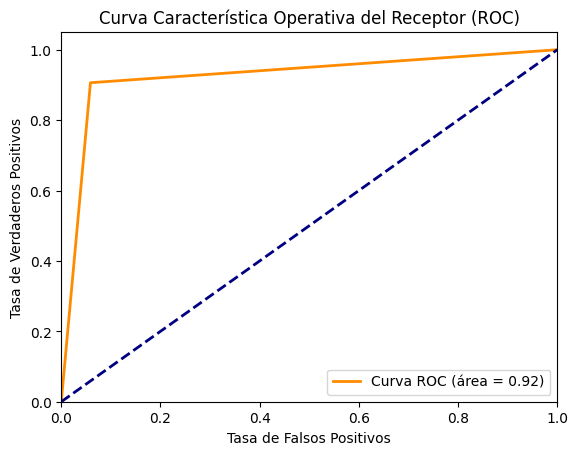

In [19]:
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Generar el reporte de clasificación para nuestro modelo
print("Reporte de Clasificación:")
print(classification_report(y_test, predictions))

# Calcular la curva ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.show()

### 12. Visualización de los resultados en el conjunto de prueba 

Esta celda crea un gráfico de la **frontera de decisión** del modelo KNN en el conjunto de prueba. Esto nos permite ver, de manera visual, cómo el modelo ha clasificado las nuevas instancias y cuáles fueron sus aciertos y errores.

Aquí está el desglose de lo que hace cada parte del código:

* **Preparación de los datos**:
    * **`X_set, y_set = sc.inverse_transform(X_test), y_test`**: Se revierte la transformación de escalado (`StandardScaler`) a los datos de prueba para que los ejes del gráfico muestren los valores originales (Edad y Salario estimado), lo que facilita su interpretación.
    * **`np.meshgrid(...)`**: Crea una "malla" de puntos que cubren todo el rango de valores de las características (Edad y Salario). Esta malla representa cada posible combinación de Edad y Salario para la cual el modelo hará una predicción.
* **Creación del gráfico de la frontera de decisión**:
    * **`plt.contourf(...)`**: Esta es la parte más importante. Para cada punto de la malla, el código hace que el modelo **prediga la clase**. Los resultados de la predicción se utilizan para colorear el fondo del gráfico. Las regiones rojas representan las áreas donde el modelo predice la clase 0 (no compra) y las regiones verdes, la clase 1 (compra). Esta frontera es la **frontera de decisión** del modelo KNN.
* **Puntos de datos reales**:
    * **`for i, j in enumerate(np.unique(y_set)): plt.scatter(...)`**: Este bucle traza los puntos de datos reales del conjunto de prueba sobre el gráfico. Los puntos rojos son los que realmente no compraron (`y_test = 0`) y los puntos verdes son los que sí compraron (`y_test = 1`).
* **Detalles del gráfico**:
    * Las líneas de código restantes (`plt.title`, `plt.xlabel`, `plt.ylabel`, `plt.legend`, `plt.show()`) añaden el título, las etiquetas de los ejes y la leyenda al gráfico para hacerlo más claro y comprensible.

El resultado final es un gráfico que te permite ver visualmente dónde el modelo **acertó** (puntos rojos en la región roja y puntos verdes en la región verde) y dónde **falló** (puntos rojos en la región verde o puntos verdes en la región roja). Esto complementa las métricas numéricas de la matriz de confusión y la exactitud.

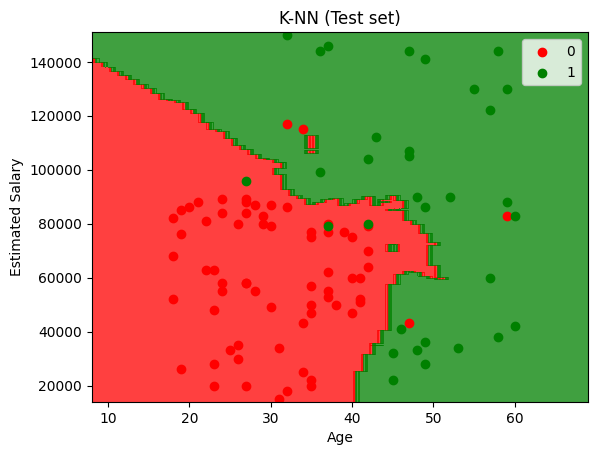

In [20]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], color = ListedColormap(('red', 'green'))(i), label = j) # Changed 'c' to 'color'
plt.title('K-NN (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()